In [9]:
import warnings
from dask import delayed

import dask
from dask.distributed import Client
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

warnings.filterwarnings('ignore')

# Create Dask client for parallel processing
client = Client(threads_per_worker=2, n_workers=2, memory_limit='2GB')
print(f"Dask client: {client}")
print(f"Dashboard: {client.dashboard_link}")

dask.config.set({"array.chunk-size": "32MB"})

LONDON_LAT = 51.5
LONDON_LON = -0.1
LAT_MIN, LAT_MAX = 50.0, 55.0
LON_MIN, LON_MAX = -5.0, 0.0


Dask client: <Client: 'tcp://127.0.0.1:38531' processes=2 threads=4, memory=3.73 GiB>
Dashboard: http://127.0.0.1:41091/status


In [10]:
# Load London daily time series from CSV
london_precip_df = pd.read_csv('london_precipitation_timeseries.csv', index_col=0, parse_dates=True)
london_precip_daily = london_precip_df['precipitation_mm'].to_xarray()

# Load combined London 5x5 dataset from NetCDF
ds_combined = xr.open_dataset('london_5x5_precipitation_2010_2024.nc')

In [7]:


# STAGE 1: LOAD LONDON DATA
print("STAGE 1: Loading London precipitation data")

ds = xr.open_zarr(
    'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3',
    chunks={'time': 24*30, 'latitude': 20, 'longitude': 20},
    storage_options=dict(token='anon'),
).sel(
    latitude=slice(LAT_MAX, LAT_MIN),
    longitude=slice(LON_MIN, LON_MAX),
    time=slice('2010-01-01', '2024-08-31')
).total_precipitation

print("Converting to daily and computing...")
london_precip_ts = ds.resample(time='D').sum().mean(dim=['latitude', 'longitude'])
london_precip_daily = (london_precip_ts * 1000).compute()

print(f"London time series: {len(london_precip_daily)} days")

london_precip_df = london_precip_daily.to_dataframe(name='precipitation_mm')
london_precip_df.to_csv('london_precipitation_timeseries.csv')
print("Time series saved")


STAGE 1: Loading London precipitation data


KeyboardInterrupt: 


STAGE 2: Calculate 95th percentile and plot CDF
95th percentile: 8.40 mm/day
Extreme days: 268


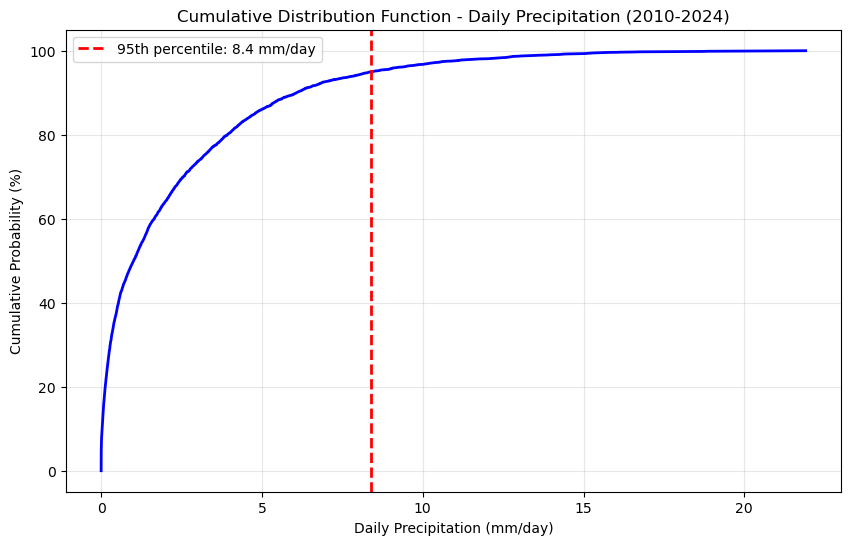

In [11]:

# STAGE 2: CALCULATE EXTREMES AND PLOT CDF
print("\nSTAGE 2: Calculate 95th percentile and plot CDF")

precip_clean = london_precip_daily.dropna(dim='time')
precip_values = precip_clean.values
precip_95th = np.percentile(precip_values, 95)

extreme_days_mask = precip_clean >= precip_95th
extreme_days = precip_clean.time[extreme_days_mask]

print(f"95th percentile: {precip_95th:.2f} mm/day")
print(f"Extreme days: {len(extreme_days)}")

sorted_precip = np.sort(precip_values)
cumulative = np.arange(1, len(sorted_precip) + 1) / len(sorted_precip)

plt.figure(figsize=(10, 6))
plt.plot(sorted_precip, cumulative * 100, 'b-', linewidth=2)
plt.axvline(precip_95th, color='red', linestyle='--', linewidth=2, 
            label=f'95th percentile: {precip_95th:.1f} mm/day')
plt.xlabel('Daily Precipitation (mm/day)')
plt.ylabel('Cumulative Probability (%)')
plt.title('Cumulative Distribution Function - Daily Precipitation (2010-2024)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('london_precipitation_cdf.png', dpi=300, bbox_inches='tight')
plt.show()


In [12]:

# STAGE 3: LOAD EUROPE COMPOSITE DATA
print("\nSTAGE 3: Load Europe region for composite analysis")

europe_lat_min, europe_lat_max = 40, 70
europe_lon_min, europe_lon_max = -20, 20

print(f"Region: {europe_lat_min}°N-{europe_lat_max}°N, "
      f"{europe_lon_min}°E-{europe_lon_max}°E")

# Load Europe region data with chunking
ds_europe = xr.open_zarr(
    'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3',
    chunks={'time': 24*30, 'latitude': 40, 'longitude': 40},
    storage_options=dict(token='anon'),
).sel(
    latitude=slice(europe_lat_max, europe_lat_min),
    longitude=slice(europe_lon_min, europe_lon_max),
    time=slice('2010-01-01', '2024-08-31')
).total_precipitation

print("Converting to daily and selecting extreme days...")
europe_daily = ds_europe.resample(time='D').sum() * 1000

# Select only extreme days
extreme_day_values = [d.values for d in extreme_days]
europe_extreme = europe_daily.sel(time=extreme_day_values, method='nearest')



STAGE 3: Load Europe region for composite analysis
Region: 40°N-70°N, -20°E-20°E
Converting to daily and selecting extreme days...


In [13]:
composite_mean = europe_extreme.mean(dim='time').compute()

print(f"Europe composite computed: shape {composite_mean.shape}")
print(f"Total extreme days in composite: {len(europe_extreme.time)}")
months_loaded = len(set([(pd.Timestamp(d.values).year, pd.Timestamp(d.values).month) for d in extreme_days]))


Europe composite computed: shape (121, 81)
Total extreme days in composite: 268



STAGE 4: Calculate precipitation anomalies
Climatology file saved locally
Using climatology variable: tp
Renamed 'valid_time' to 'time' dimension
Converted climatology from meters to millimeters
Anomaly computed using 1981-2020 climatology

STAGE 5: Creating composite maps


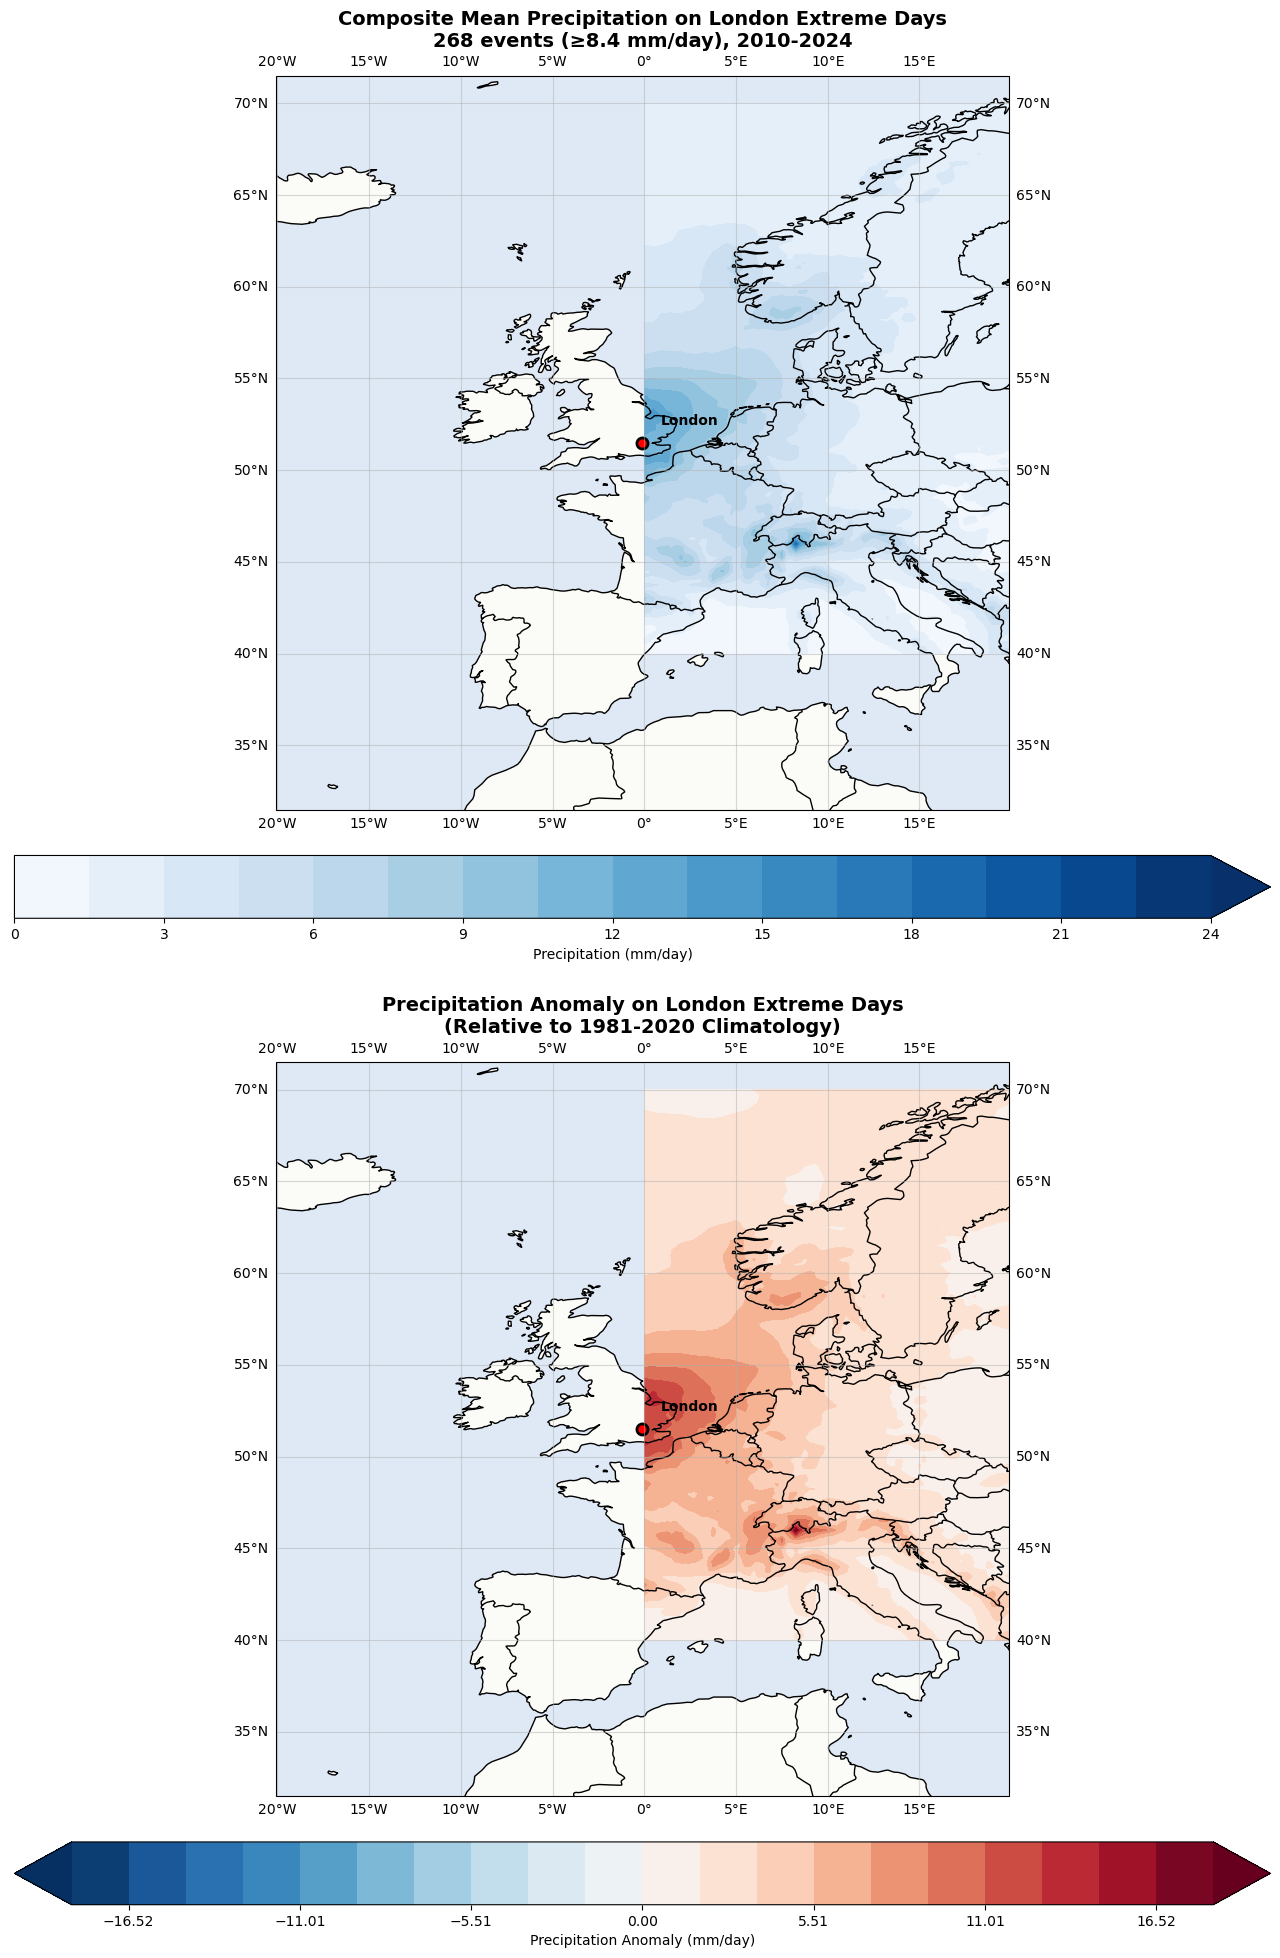

In [14]:

# STAGE 4: CALCULATE ANOMALY
print("\nSTAGE 4: Calculate precipitation anomalies")

try:
    ds_climo = xr.open_dataset(
        'https://www.atmos.illinois.edu/~snesbitt/data/'
        'ERA-5_total_precipitation_monthly-1981-2020.nc', 
        engine='h5netcdf'
    )
    ds_climo.to_netcdf('ERA-5_total_precipitation_monthly-1981-2020.nc')
    print("Climatology file saved locally")
    
    precip_var = list(ds_climo.data_vars)[0]
    print(f"Using climatology variable: {precip_var}")
    
    europe_climo = ds_climo[precip_var].sel(
        latitude=slice(composite_mean.latitude.max(), 
                      composite_mean.latitude.min()),
        longitude=slice(composite_mean.longitude.min(), 
                       composite_mean.longitude.max())
    )
    
    if 'valid_time' in europe_climo.dims:
        europe_climo = europe_climo.rename({'valid_time': 'time'})
        print("Renamed 'valid_time' to 'time' dimension")
    
    overall_clim = europe_climo.mean(dim='time')
    
    if overall_clim.max() < 1:
        overall_clim = overall_clim * 1000
        print("Converted climatology from meters to millimeters")
    
    overall_clim = overall_clim / 30.44
    composite_anomaly = composite_mean - overall_clim
    
    print("Anomaly computed using 1981-2020 climatology")
    
except Exception as e:
    print(f"Climatology loading failed: {e}")

# STAGE 5: CREATE COMPOSITE MAPS
print("\nSTAGE 5: Creating composite maps")

fig = plt.figure(figsize=(16, 20))
map_extent = [LONDON_LON - 20, LONDON_LON + 20, 
              LONDON_LAT - 20, LONDON_LAT + 20]

ax1 = fig.add_subplot(2, 1, 1, projection=ccrs.PlateCarree())
ax1.set_extent(map_extent, crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.COASTLINE)
ax1.add_feature(cfeature.BORDERS)
ax1.add_feature(cfeature.OCEAN, alpha=0.3)
ax1.add_feature(cfeature.LAND, alpha=0.2)

levels_mean = np.arange(0, 25, 1.5)
cs1 = ax1.contourf(composite_mean.longitude, composite_mean.latitude, 
                   composite_mean, levels=levels_mean, cmap='Blues', 
                   extend='max', transform=ccrs.PlateCarree())

ax1.plot(LONDON_LON, LONDON_LAT, 'ro', markersize=8, 
         markeredgecolor='black', markeredgewidth=2, 
         transform=ccrs.PlateCarree())
ax1.text(LONDON_LON + 1, LONDON_LAT + 1, 'London', 
         transform=ccrs.PlateCarree(), fontsize=10, fontweight='bold')

ax1.set_title(f'Composite Mean Precipitation on London Extreme Days\n'
             f'{len(extreme_days)} events (≥{precip_95th:.1f} mm/day), '
             f'2010-2024', fontsize=14, fontweight='bold')
plt.colorbar(cs1, ax=ax1, orientation='horizontal', pad=0.05, 
            shrink=0.8, label='Precipitation (mm/day)')

ax1.gridlines(draw_labels=True, alpha=0.5)

ax2 = fig.add_subplot(2, 1, 2, projection=ccrs.PlateCarree())
ax2.set_extent(map_extent, crs=ccrs.PlateCarree())
ax2.add_feature(cfeature.COASTLINE)
ax2.add_feature(cfeature.BORDERS)
ax2.add_feature(cfeature.OCEAN, alpha=0.3)
ax2.add_feature(cfeature.LAND, alpha=0.2)

max_anom = max(abs(composite_anomaly.min().values), 
               abs(composite_anomaly.max().values))
levels_anom = np.linspace(-max_anom, max_anom, 21)
cs2 = ax2.contourf(composite_anomaly.longitude, composite_anomaly.latitude,
                   composite_anomaly, levels=levels_anom, cmap='RdBu_r', 
                   extend='both', transform=ccrs.PlateCarree())

ax2.plot(LONDON_LON, LONDON_LAT, 'ro', markersize=8, 
         markeredgecolor='black', markeredgewidth=2, 
         transform=ccrs.PlateCarree())
ax2.text(LONDON_LON + 1, LONDON_LAT + 1, 'London', 
         transform=ccrs.PlateCarree(), fontsize=10, fontweight='bold')

ax2.set_title('Precipitation Anomaly on London Extreme Days\n'
             '(Relative to 1981-2020 Climatology)', 
             fontsize=14, fontweight='bold')
plt.colorbar(cs2, ax=ax2, orientation='horizontal', pad=0.05, 
            shrink=0.8, label='Precipitation Anomaly (mm/day)')

ax2.gridlines(draw_labels=True, alpha=0.5)

plt.tight_layout()
plt.savefig('london_extreme_precip_composite_maps.png', dpi=300, 
            bbox_inches='tight')
plt.show()

